# KAMP GMST-Power Phase 1 — 15분 단위 전처리
hourly wide CSV -> 15분 long CSV. Spec: `document/KAMP_GMST_Power_project_proposal.md` §4, §4.2, §18.

## 1. 데이터 로드

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams["font.family"] = "NanumSquare"
plt.rcParams["axes.unicode_minus"] = False

SRC = "5. 자원 최적화 AI 데이터셋/okm_augumented_2021.csv"
OUT = "5. 자원 최적화 AI 데이터셋/okm_15min_2021.csv"

df = pl.read_csv(SRC, encoding="utf8-lossy", infer_schema_length=10000)
print(df.shape)
print(df.schema)
df.head()

(6168, 18)
Schema({'날짜': Int64, '시간': Int64, '15분': Int64, '30분': Int64, '45분': Int64, '60분': Int64, '평균': Int64, '생산량': Int64, '기온': Float64, '풍속': Float64, '습도': Int64, '강수량': Float64, '전기요금(계절)': Float64, 'day': Int64, 'd': Int64, 'm': Int64, '공장인원': Float64, '인건비': Float64})


날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,f64,f64,i64,i64,i64,f64,f64
20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


## 2. Wide → Long 변환 + datetime 생성
타임스탬프는 interval-start 라벨: 15분→HH:00, 30분→HH:15, 45분→HH:30, 60분→HH:45.
`시간` 컬럼은 두 날짜(20210713, 20210715)에서 손상되어 있어(아래 3절에서 확인), 파일 내 원래 행 순서(날짜별 0~23 위치)를 실제 시간으로 사용한다 — 손상되지 않은 255개 날짜 전부에서 이 위치가 `시간` 값과 정확히 일치하므로 안전한 재구성이다.

In [2]:
df = df.with_row_index("row_idx")
df = df.with_columns((pl.col("row_idx") - pl.col("row_idx").min().over("날짜")).alias("hour"))

anomaly = df.filter(pl.col("시간") != pl.col("hour"))
print("시간 컬럼 이상치 행 수:", anomaly.height, "| 해당 날짜:", anomaly["날짜"].unique().sort().to_list())

value_cols = ["15분", "30분", "45분", "60분"]
k_map = {"15분": 0, "30분": 1, "45분": 2, "60분": 3}
index_cols = [c for c in df.columns if c not in value_cols]

long = df.unpivot(on=value_cols, index=index_cols, variable_name="q_label", value_name="전력")
long = long.with_columns(pl.col("q_label").replace_strict(k_map).cast(pl.Int64).alias("k"))
long = long.with_columns(pl.col("날짜").cast(pl.Utf8).str.strptime(pl.Date, "%Y%m%d").alias("date"))
long = long.with_columns(
    (pl.col("date").cast(pl.Datetime) + pl.duration(hours=pl.col("hour"), minutes=pl.col("k") * 15)).alias("datetime")
)
long = long.with_columns((4 * pl.col("hour") + pl.col("k")).alias("quarter"))
long = long.sort(["row_idx", "k"])

long.select("날짜", "hour", "q_label", "datetime", "quarter", "전력").with_columns(
    pl.col("datetime").dt.strftime("%Y.%m.%d %H:%M:%S").alias("datetime_str")
).head()

시간 컬럼 이상치 행 수: 48 | 해당 날짜: [20210713, 20210715]


날짜,hour,q_label,datetime,quarter,전력,datetime_str
i64,u32,str,datetime[μs],i64,i64,str
20210101,0,"""15분""",2021-01-01 00:00:00,0,62,"""2021.01.01 00:00:00"""
20210101,0,"""30분""",2021-01-01 00:15:00,1,61,"""2021.01.01 00:15:00"""
20210101,0,"""45분""",2021-01-01 00:30:00,2,61,"""2021.01.01 00:30:00"""
20210101,0,"""60분""",2021-01-01 00:45:00,3,61,"""2021.01.01 00:45:00"""
20210101,1,"""15분""",2021-01-01 01:00:00,4,96,"""2021.01.01 01:00:00"""


## 3. 타임스탬프 검증

In [3]:
from datetime import timedelta

assert long["datetime"].n_unique() == long.height, "datetime 중복 존재"

diffs = long.sort("datetime")["datetime"].diff().drop_nulls().unique().to_list()
print("15분 그리드 간격 종류:", diffs)
assert diffs == [timedelta(minutes=15)], f"연속된 15분 그리드가 아님: {diffs}"

per_day = long.group_by("날짜").agg(pl.len().alias("n"))
bad_days = per_day.filter(pl.col("n") != 96)
print("96개(24시간x4) 아닌 날짜 수:", bad_days.height)
assert bad_days.height == 0

chk = long.with_columns(
    pl.col("datetime").dt.day().alias("exp_d"),
    pl.col("datetime").dt.month().alias("exp_m"),
    pl.col("datetime").dt.weekday().alias("exp_day"),
)
mismatch_d = chk.filter(pl.col("exp_d") != pl.col("d")).height
mismatch_m = chk.filter(pl.col("exp_m") != pl.col("m")).height
mismatch_day = chk.filter(pl.col("exp_day") != pl.col("day")).height
print(f"d/m/day 불일치 행 수: d={mismatch_d}, m={mismatch_m}, day(ISO weekday)={mismatch_day}")
assert (mismatch_d, mismatch_m, mismatch_day) == (0, 0, 0), "day/d/m이 datetime과 불일치"

print("타임스탬프 검증 통과: 고유, 15분 연속 그리드, 날짜당 96개, day/d/m 일치")

15분 그리드 간격 종류: [datetime.timedelta(seconds=900)]
96개(24시간x4) 아닌 날짜 수: 0
d/m/day 불일치 행 수: d=0, m=0, day(ISO weekday)=0
타임스탬프 검증 통과: 고유, 15분 연속 그리드, 날짜당 96개, day/d/m 일치


## 4. 리키지 체크 및 컬럼 정리
`평균 ≈ mean(15분..60분)`, `공장인원 ≈ 생산량 / (15분+30분+45분+60분)` 확인 후 평균/공장인원/day/d/m 컬럼을 제거한다(datetime에서 파생 가능하거나 리키지 컬럼).

In [4]:
denom = pl.col("15분") + pl.col("30분") + pl.col("45분") + pl.col("60분")
leak_chk = df.with_columns(
    (denom / 4).alias("avg_calc"),
    pl.when(denom > 0).then(pl.col("생산량") / denom).otherwise(None).alias("employee_calc"),
)
avg_diff = (leak_chk["평균"] - leak_chk["avg_calc"]).abs()
emp_diff = (leak_chk["공장인원"] - leak_chk["employee_calc"]).abs()
print(f"평균 vs mean(15..60분) 차이: max={avg_diff.max():.3f}, mean={avg_diff.mean():.4f} (반올림 오차 수준)")
print(f"공장인원 vs 생산량/합 차이: max={emp_diff.max():.2e}, mean={emp_diff.mean():.2e} (부동소수 오차 수준)")
assert avg_diff.max() < 1.0, "평균 리키지 관계가 깨짐"
assert emp_diff.max() < 1e-6, "공장인원 리키지 관계가 깨짐"
print("리키지 확인됨 -> 평균, 공장인원 드롭. day/d/m은 datetime에서 파생 가능하므로 드롭.")

long = long.drop("평균", "공장인원", "day", "d", "m")
long.head()

평균 vs mean(15..60분) 차이: max=0.500, mean=0.2333 (반올림 오차 수준)
공장인원 vs 생산량/합 차이: max=4.94e-09, mean=1.53e-10 (부동소수 오차 수준)
리키지 확인됨 -> 평균, 공장인원 드롭. day/d/m은 datetime에서 파생 가능하므로 드롭.


row_idx,날짜,시간,생산량,기온,풍속,습도,강수량,전기요금(계절),인건비,hour,q_label,전력,k,date,datetime,quarter
u32,i64,i64,i64,f64,f64,i64,f64,f64,f64,u32,str,i64,i64,date,datetime[μs],i64
0,20210101,0,0,-3.2,2.4,71,0.0,109.8,1.5,0,"""15분""",62,0,2021-01-01,2021-01-01 00:00:00,0
0,20210101,0,0,-3.2,2.4,71,0.0,109.8,1.5,0,"""30분""",61,1,2021-01-01,2021-01-01 00:15:00,1
0,20210101,0,0,-3.2,2.4,71,0.0,109.8,1.5,0,"""45분""",61,2,2021-01-01,2021-01-01 00:30:00,2
0,20210101,0,0,-3.2,2.4,71,0.0,109.8,1.5,0,"""60분""",61,3,2021-01-01,2021-01-01 00:45:00,3
1,20210101,1,0,-4.5,1.5,77,0.0,109.8,1.5,1,"""15분""",96,0,2021-01-01,2021-01-01 01:00:00,4


## 5. 중복 일간 패턴 분석
각 날짜의 96개(quarter-of-day) 전력 벡터가 다른 날짜와 완전히 동일한 경우를 센다.

In [5]:
pat = long.sort(["날짜", "quarter"]).group_by("날짜", maintain_order=True).agg(pl.col("전력").alias("vec"))

groups = defaultdict(list)
for row in pat.iter_rows(named=True):
    groups[tuple(row["vec"])].append(row["날짜"])
dup_groups = {k: v for k, v in groups.items() if len(v) > 1}
dup_days = sum(len(v) for v in dup_groups.values())

print(f"전체 날짜 수: {pat.height}, 중복 그룹 수: {len(dup_groups)}, 중복에 연루된 날짜 수: {dup_days}")
print("예시 중복 그룹 (최대 5개):")
for v in list(dup_groups.values())[:5]:
    print(" ", v)

전체 날짜 수: 257, 중복 그룹 수: 45, 중복에 연루된 날짜 수: 160
예시 중복 그룹 (최대 5개):
  [20210102, 20210205, 20210306, 20210313, 20210320, 20210327, 20210605]
  [20210103, 20210606]
  [20210104, 20210204, 20210304, 20210604]
  [20210105, 20210106, 20210112, 20210113, 20210119, 20210120, 20210126, 20210127, 20210131, 20210305, 20210312, 20210319, 20210326, 20210331, 20210530]
  [20210107, 20210607]


## 6. 시각화

### a. 전체 15분 전력 시계열 + 1일 이동평균

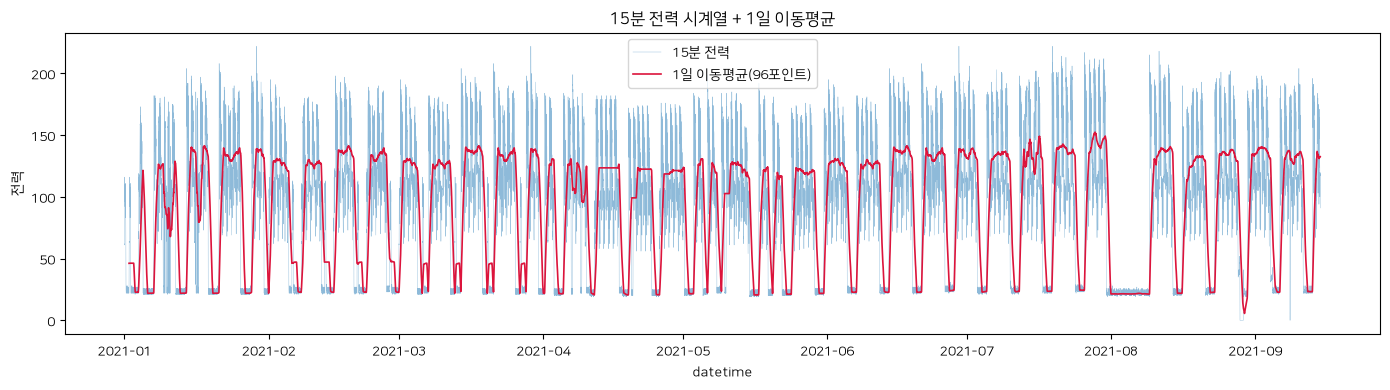

In [6]:
s = long.sort("datetime").select("datetime", "전력")
roll = s.with_columns(pl.col("전력").rolling_mean(window_size=96).alias("roll_1d"))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll["datetime"], roll["전력"], lw=0.3, alpha=0.5, label="15분 전력")
ax.plot(roll["datetime"], roll["roll_1d"], lw=1.2, color="crimson", label="1일 이동평균(96포인트)")
ax.set_title("15분 전력 시계열 + 1일 이동평균")
ax.set_xlabel("datetime")
ax.set_ylabel("전력")
ax.legend()
fig.tight_layout()
plt.show()

### b. 히트맵: 날짜 × quarter-of-day

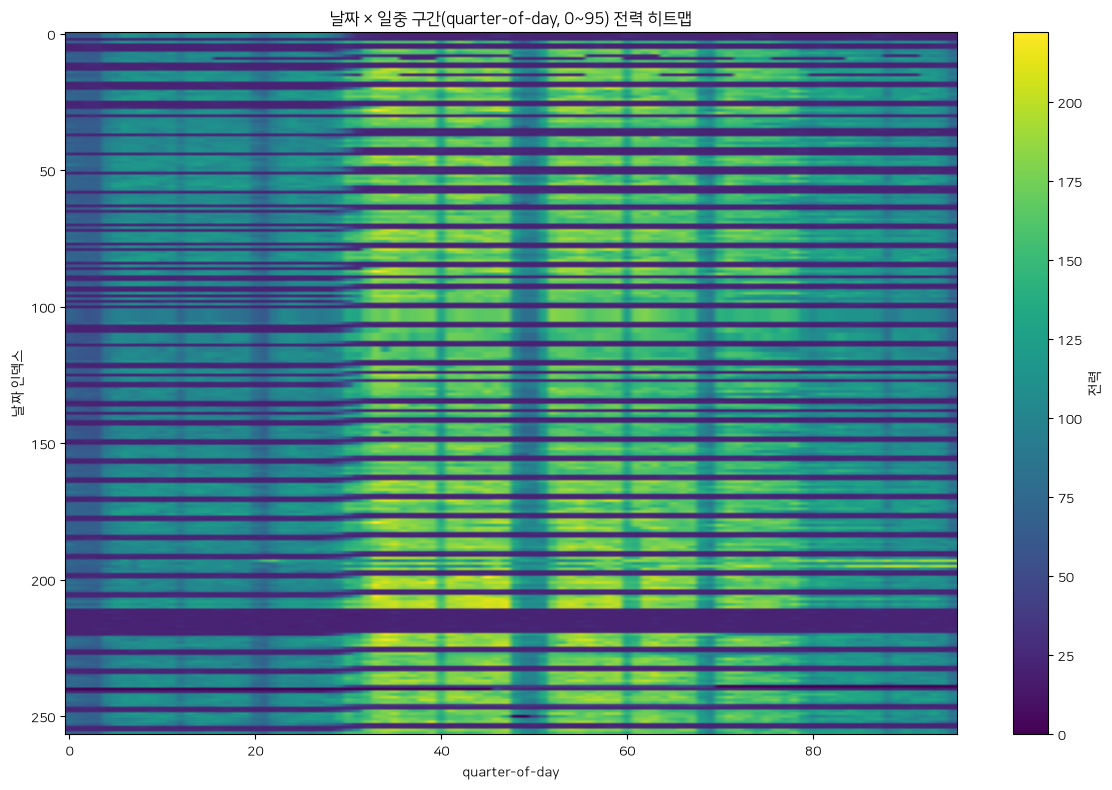

In [7]:
heat = long.sort(["날짜", "quarter"]).pivot(on="quarter", index="날짜", values="전력").sort("날짜")
dates = heat["날짜"].to_list()
mat = heat.drop("날짜").to_numpy()

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(mat, aspect="auto", cmap="viridis")
ax.set_title("날짜 × 일중 구간(quarter-of-day, 0~95) 전력 히트맵")
ax.set_xlabel("quarter-of-day")
ax.set_ylabel("날짜 인덱스")
fig.colorbar(im, ax=ax, label="전력")
fig.tight_layout()
plt.show()

### c. 평일/주말 분리 quarter-of-day 평균 프로파일

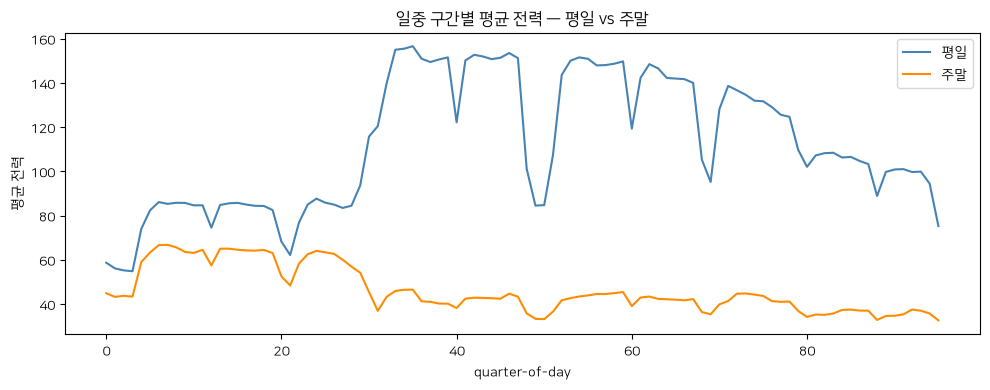

In [8]:
prof = long.with_columns((pl.col("datetime").dt.weekday() >= 6).alias("is_weekend"))
prof = prof.group_by(["quarter", "is_weekend"]).agg(pl.col("전력").mean().alias("mean_전력")).sort("quarter")

fig, ax = plt.subplots(figsize=(10, 4))
for is_weekend, label, color in [(False, "평일", "steelblue"), (True, "주말", "darkorange")]:
    sub = prof.filter(pl.col("is_weekend") == is_weekend).sort("quarter")
    ax.plot(sub["quarter"], sub["mean_전력"], label=label, color=color)
ax.set_title("일중 구간별 평균 전력 — 평일 vs 주말")
ax.set_xlabel("quarter-of-day")
ax.set_ylabel("평균 전력")
ax.legend()
fig.tight_layout()
plt.show()

### d. 전력 히스토그램 + p95/p99

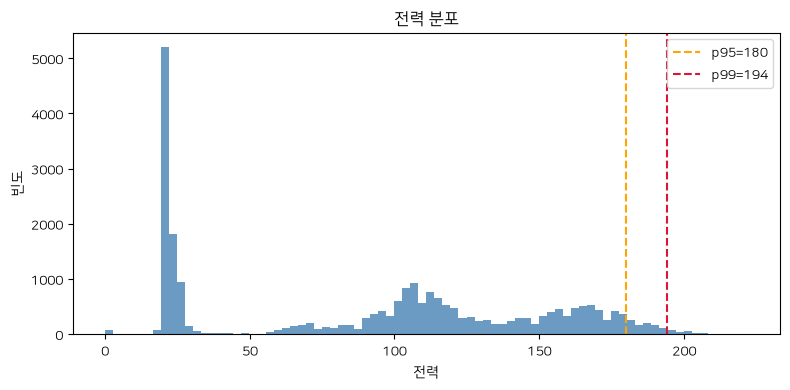

In [9]:
p95, p99 = long["전력"].quantile(0.95), long["전력"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(long["전력"], bins=80, color="steelblue", alpha=0.8)
ax.axvline(p95, color="orange", ls="--", label=f"p95={p95:.0f}")
ax.axvline(p99, color="crimson", ls="--", label=f"p99={p99:.0f}")
ax.set_title("전력 분포")
ax.set_xlabel("전력")
ax.set_ylabel("빈도")
ax.legend()
fig.tight_layout()
plt.show()

### e. 산점도: 전력 vs 생산량, 전력 vs 기온

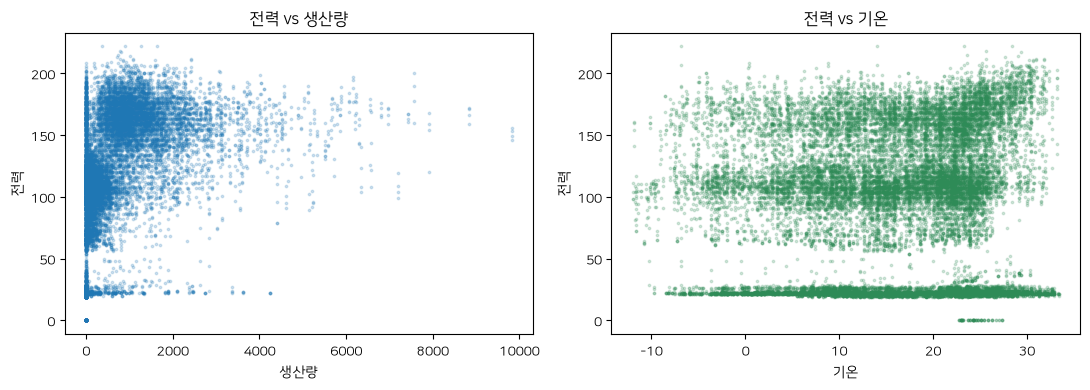

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(long["생산량"], long["전력"], s=3, alpha=0.2)
axes[0].set_xlabel("생산량")
axes[0].set_ylabel("전력")
axes[0].set_title("전력 vs 생산량")

axes[1].scatter(long["기온"], long["전력"], s=3, alpha=0.2, color="seagreen")
axes[1].set_xlabel("기온")
axes[1].set_ylabel("전력")
axes[1].set_title("전력 vs 기온")
fig.tight_layout()
plt.show()

### f. 리키지 산점도: 공장인원 vs 생산량/(15분+30분+45분+60분)

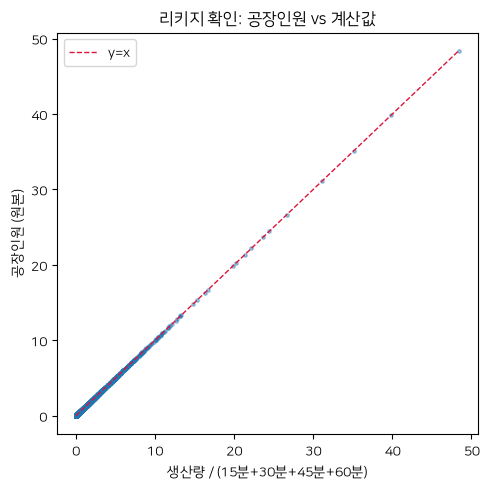

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(leak_chk["employee_calc"], leak_chk["공장인원"], s=6, alpha=0.4)
lims = [0, float(leak_chk["공장인원"].max())]
ax.plot(lims, lims, color="crimson", ls="--", lw=1, label="y=x")
ax.set_xlabel("생산량 / (15분+30분+45분+60분)")
ax.set_ylabel("공장인원 (원본)")
ax.set_title("리키지 확인: 공장인원 vs 계산값")
ax.legend()
fig.tight_layout()
plt.show()

## 7. 저장 및 재검증

In [12]:
out = long.select(
    "datetime", "전력", "생산량", "기온", "풍속", "습도", "강수량", "전기요금(계절)", "인건비"
).sort("datetime")

assert out.height == 24672, f"예상 행 수(24672)와 다름: {out.height}"
assert out.columns == ["datetime", "전력", "생산량", "기온", "풍속", "습도", "강수량", "전기요금(계절)", "인건비"]

out.write_csv(OUT, datetime_format="%Y.%m.%d %H:%M:%S")
print("저장 완료:", OUT, out.shape)

reread = pl.read_csv(OUT)
print(reread.head(3))
assert reread["datetime"][0] == "2021.01.01 00:00:00"
assert reread["datetime"][1] == "2021.01.01 00:15:00"
assert reread.height == 24672
print("재검증 통과: datetime 문자열 포맷 round-trip 확인됨")

저장 완료: 5. 자원 최적화 AI 데이터셋/okm_15min_2021.csv (24672, 9)
shape: (3, 9)
┌─────────────────────┬──────┬────────┬──────┬───┬──────┬────────┬────────────────┬────────┐
│ datetime            ┆ 전력 ┆ 생산량 ┆ 기온 ┆ … ┆ 습도 ┆ 강수량 ┆ 전기요금(계절) ┆ 인건비 │
│ ---                 ┆ ---  ┆ ---    ┆ ---  ┆   ┆ ---  ┆ ---    ┆ ---            ┆ ---    │
│ str                 ┆ i64  ┆ i64    ┆ f64  ┆   ┆ i64  ┆ f64    ┆ f64            ┆ f64    │
╞═════════════════════╪══════╪════════╪══════╪═══╪══════╪════════╪════════════════╪════════╡
│ 2021.01.01 00:00:00 ┆ 62   ┆ 0      ┆ -3.2 ┆ … ┆ 71   ┆ 0.0    ┆ 109.8          ┆ 1.5    │
│ 2021.01.01 00:15:00 ┆ 61   ┆ 0      ┆ -3.2 ┆ … ┆ 71   ┆ 0.0    ┆ 109.8          ┆ 1.5    │
│ 2021.01.01 00:30:00 ┆ 61   ┆ 0      ┆ -3.2 ┆ … ┆ 71   ┆ 0.0    ┆ 109.8          ┆ 1.5    │
└─────────────────────┴──────┴────────┴──────┴───┴──────┴────────┴────────────────┴────────┘
재검증 통과: datetime 문자열 포맷 round-trip 확인됨
